# O tradeoff entre viés e variância

objetivo de aprendizagem:
- Descrever a função custo de perda logarítmica da regressão logística
- Implementar o procedimento de grandiente descendente para estimar parametros do modelo
- Articular as suposições estatísticas formais do modelo de regressão logística
- Caracterizar o trade-off entre viés e variância e usá-lo para melhorar os modelos
- Formular o lasso e a regularização ridge e usá-los no scikit-learn
- Projetar uma função para selecionar hiperparâmetros de regularização por validação cruzada
- Criar características de integração por engenharia para melhorar um modelo de subajuste

In [1]:
!pip install numpy
!pip install matplotlib

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
X_poly = np.linspace(-3, 5, 81)
print(X_poly[:5], '...', X_poly[-5:])

[-3.  -2.9 -2.8 -2.7 -2.6] ... [4.6 4.7 4.8 4.9 5. ]


Text(0.5, 1.0, 'error surface')

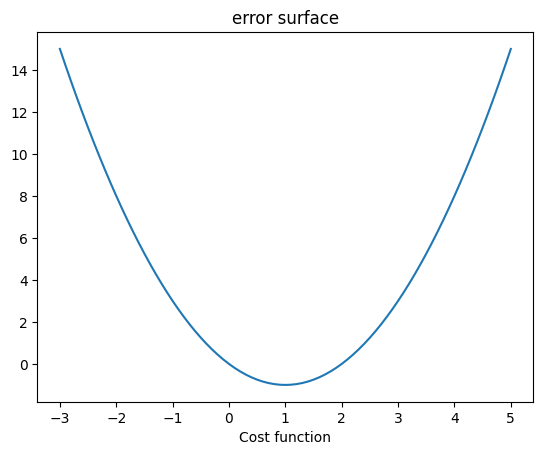

In [7]:
#função que retorna o valor da função custo
def cost_function(X):
  return X * (X-2)
y_poly = cost_function(X_poly)
plt.plot(X_poly, y_poly)
plt.xlabel('Parameter value')
plt.xlabel('Cost function')
plt.title('error surface')


In [32]:
#função para o valor do gradiente. Ela é uma derivada analítica da função custo.
def gradient(X):
  return (2*X) - 2
x_start = 4.5
learning_rate = 0.75
x_next = x_start - gradient(x_start)*learning_rate
x_next

-0.75

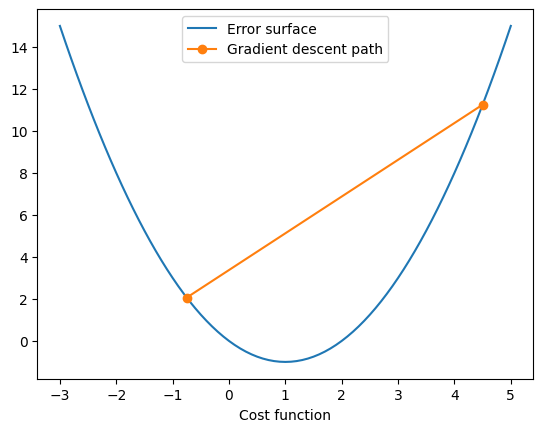

In [33]:
#plotagem do caminho do gradiente descendente, do ponto inicial ao próximo ponto:
plt.plot(X_poly, y_poly)
plt.plot([x_start, x_next], [cost_function(x_start), cost_function(x_next)], '-o')
plt.xlabel('Parameter value')
plt.xlabel('Cost function')
plt.legend(['Error surface', 'Gradient descent path'])

In [34]:
#14 iterações para convergir em direção ao mínimo local da função custo
iterations = 15
x_path = np.empty(iterations,)
x_path[0] = x_start
for iteration_count in range(1, iterations):
  derivate = gradient(x_path[iteration_count-1])
  x_path[iteration_count] = x_path[iteration_count-1] - (derivate* learning_rate)
x_path

array([ 4.5       , -0.75      ,  1.875     ,  0.5625    ,  1.21875   ,
        0.890625  ,  1.0546875 ,  0.97265625,  1.01367188,  0.99316406,
        1.00341797,  0.99829102,  1.00085449,  0.99957275,  1.00021362])

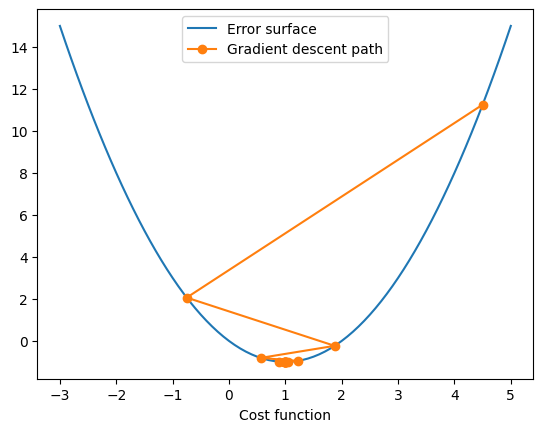

In [35]:
#plotar o caminho do gradiente descendente
plt.plot(X_poly, y_poly)
plt.plot(x_path, cost_function(x_path), '-o')
plt.xlabel('Parameter value')
plt.xlabel('Cost function')
plt.legend(['Error surface', 'Gradient descent path'])

In [ ]:
from google.colab import drive
drive.mount('/content/drive')